In [2]:
import os
import cv2
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import kagglehub
from tqdm import tqdm
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [3]:
SEED = 42
IMG_SIZE = 32
NUM_FRAMES = 10
BATCH_SIZE = 16
EPOCHS = 30
LEARNING_RATE = 1e-3
PATIENCE = 10
TEST_SIZE = 0.2
NUM_WORKERS = 2

SELECTED_CLASSES = ["Walking", "Sitting", "Standing Still"]
PREPROCESS_DIR = "./preprocessed_3classes"
VIDEO_EXTENSIONS = (".mp4", ".avi", ".mov", ".mkv", ".webm")

In [4]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type != "cuda":
    print("Warning: GPU is not enabled. On Colab, choose Runtime > Change runtime type > T4 GPU")

torch.backends.cudnn.benchmark = True
if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

AMP_ENABLED = device.type == "cuda"
scaler = torch.amp.GradScaler("cuda") if AMP_ENABLED else None

os.makedirs(PREPROCESS_DIR, exist_ok=True)
train_file = os.path.join(PREPROCESS_DIR, "train.pt")
test_file = os.path.join(PREPROCESS_DIR, "test.pt")


Using device: cpu


In [5]:
def normalize_name(name):
    return name.lower().replace("_", " ").replace("-", " ").strip()

In [6]:
def find_dataset_root(base_path):
    """
    Find the directory that directly contains class folders.
    """
    candidates = []
    for root, dirs, files in os.walk(base_path):
        norm_dirs = [normalize_name(d) for d in dirs]
        score = 0
        for target in SELECTED_CLASSES:
            if any(normalize_name(target) == nd or normalize_name(target) in nd or nd in normalize_name(target) for nd in norm_dirs):
                score += 1
        if score >= 2:
            candidates.append((score, root))

    if candidates:
        candidates.sort(reverse=True)
        return candidates[0][1]

    return base_path

In [7]:
def map_selected_classes(dataset_root):
    """
    Map required class names to actual folder paths robustly.
    """
    available_dirs = []
    for item in sorted(os.listdir(dataset_root)):
        full = os.path.join(dataset_root, item)
        if os.path.isdir(full):
            available_dirs.append((item, full))

    selected_paths = {}
    for target in SELECTED_CLASSES:
        target_norm = normalize_name(target)
        found = None

        for folder_name, folder_path in available_dirs:
            folder_norm = normalize_name(folder_name)
            if folder_norm == target_norm or target_norm in folder_norm or folder_norm in target_norm:
                found = folder_path
                break

        if found is not None:
            selected_paths[target] = found

    return selected_paths

In [8]:
def extract_frames_fast(video_path, num_frames=NUM_FRAMES, img_size=IMG_SIZE):
    """
    Faster than repeated cap.set for every frame in many cases.
    Reads sequentially and keeps only needed frames.
    """
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frames = []

    if total_frames <= 0:
        raw = []
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (img_size, img_size))
            raw.append(frame)

        cap.release()

        if len(raw) == 0:
            raw = [np.zeros((img_size, img_size, 3), dtype=np.uint8)]

        idxs = np.linspace(0, len(raw) - 1, num_frames).astype(int)
        frames = [raw[i] for i in idxs]
    else:
        target_idxs = set(np.linspace(0, total_frames - 1, num_frames).astype(int))
        current_idx = 0

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            if current_idx in target_idxs:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame = cv2.resize(frame, (img_size, img_size))
                frames.append(frame)

                if len(frames) == num_frames:
                    break

            current_idx += 1

        cap.release()

    if len(frames) == 0:
        frames = [np.zeros((img_size, img_size, 3), dtype=np.uint8)]

    while len(frames) < num_frames:
        frames.append(frames[-1])

    video = np.array(frames[:num_frames], dtype=np.float32) / 255.0
    video = np.transpose(video, (0, 3, 1, 2))   # (T, C, H, W)
    return video

In [9]:
if os.path.exists(train_file) and os.path.exists(test_file):
    print("Loading preprocessed data...")
    X_train, y_train = torch.load(train_file, map_location="cpu")
    X_test, y_test = torch.load(test_file, map_location="cpu")
else:
    print("Preprocessed files not found. Downloading dataset and preprocessing...")

    dataset_path = kagglehub.dataset_download("sharjeelmazhar/human-activity-recognition-video-dataset")
    print("Downloaded to:", dataset_path)

    dataset_root = find_dataset_root(dataset_path)
    print("Dataset root:", dataset_root)

    selected_paths = map_selected_classes(dataset_root)
    if len(selected_paths) != len(SELECTED_CLASSES):
        raise ValueError(f"Could not find all selected classes. Found: {list(selected_paths.keys())}")

    print("Classes used:", SELECTED_CLASSES)
    print("Preprocessing videos (first time only)...")

    video_paths = []
    labels = []

    for label_idx, cls in enumerate(SELECTED_CLASSES):
        class_dir = selected_paths[cls]
        videos = []
        for ext in VIDEO_EXTENSIONS:
            videos.extend(glob.glob(os.path.join(class_dir, f"*{ext}")))
            videos.extend(glob.glob(os.path.join(class_dir, f"*{ext.upper()}")))

        videos = sorted(videos)
        print(f"Loading {cls} ({len(videos)} videos)")

        for vp in videos:
            video_paths.append(vp)
            labels.append(label_idx)

    if len(video_paths) == 0:
        raise ValueError("No videos found for selected classes.")

    train_paths, test_paths, train_labels, test_labels = train_test_split(
        video_paths,
        labels,
        test_size=TEST_SIZE,
        random_state=SEED,
        stratify=labels,
        shuffle=True
    )

    X_train_list = []
    for vp in tqdm(train_paths):
        X_train_list.append(extract_frames_fast(vp))

    X_test_list = []
    for vp in tqdm(test_paths):
        X_test_list.append(extract_frames_fast(vp))

    X_train = torch.tensor(np.array(X_train_list), dtype=torch.float32)
    y_train = torch.tensor(np.array(train_labels), dtype=torch.long)
    X_test = torch.tensor(np.array(X_test_list), dtype=torch.float32)
    y_test = torch.tensor(np.array(test_labels), dtype=torch.long)

    torch.save((X_train, y_train), train_file)
    torch.save((X_test, y_test), test_file)

    print("Preprocessing done and saved.")

print("Train tensor shape:", X_train.shape)
print("Test tensor shape :", X_test.shape)


Preprocessed files not found. Downloading dataset and preprocessing...


100%|██████████| 14.8G/14.8G [02:50<00:00, 93.1MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/sharjeelmazhar/human-activity-recognition-video-dataset/versions/1
Dataset root: /root/.cache/kagglehub/datasets/sharjeelmazhar/human-activity-recognition-video-dataset/versions/1/Human Activity Recognition - Video Dataset
Classes used: ['Walking', 'Sitting', 'Standing Still']
Preprocessing videos (first time only)...
Loading Walking (171 videos)
Loading Sitting (156 videos)
Loading Standing Still (174 videos)


100%|██████████| 101/101 [06:53<00:00,  4.10s/it]


Preprocessing done and saved.
Train tensor shape: torch.Size([400, 10, 3, 32, 32])
Test tensor shape : torch.Size([101, 10, 3, 32, 32])


In [10]:
full_train_dataset = TensorDataset(X_train, y_train)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

split_generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=split_generator
)

test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)


In [11]:
class FastCNNLSTM(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   # 32 -> 16

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   # 16 -> 8

            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.lstm = nn.LSTM(
            input_size=64,
            hidden_size=64,
            batch_first=True
        )
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        # x: (B, T, C, H, W)
        B, T, C, H, W = x.shape
        x = x.view(B * T, C, H, W)
        x = self.cnn(x).view(B * T, -1)
        x = x.view(B, T, -1)
        _, (h, _) = self.lstm(x)
        x = h[-1]
        return self.fc(x)

NUM_CLASSES = len(SELECTED_CLASSES)
model = FastCNNLSTM(NUM_CLASSES).to(device)
print(model)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

FastCNNLSTM(
  (cnn): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (lstm): LSTM(64, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=3, bias=True)
)


In [12]:
class EarlyStopping:
    def __init__(self, patience=PATIENCE, path="best_final.pth"):
        self.patience = patience
        self.path = path
        self.best_acc = 0.0
        self.counter = 0

    def __call__(self, val_acc, model):
        if val_acc > self.best_acc:
            self.best_acc = val_acc
            self.counter = 0
            torch.save(model.state_dict(), self.path)
            return False
        else:
            self.counter += 1
            return self.counter >= self.patience

early_stop = EarlyStopping()



TRAINING


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


E1: Train Acc 0.306, Val Acc 0.375
E2: Train Acc 0.369, Val Acc 0.350
E3: Train Acc 0.403, Val Acc 0.412
E4: Train Acc 0.441, Val Acc 0.512
E5: Train Acc 0.450, Val Acc 0.475
E6: Train Acc 0.478, Val Acc 0.500
E7: Train Acc 0.487, Val Acc 0.525
E8: Train Acc 0.537, Val Acc 0.512
E9: Train Acc 0.544, Val Acc 0.562
E10: Train Acc 0.566, Val Acc 0.487
E11: Train Acc 0.594, Val Acc 0.613
E12: Train Acc 0.613, Val Acc 0.550
E13: Train Acc 0.625, Val Acc 0.512
E14: Train Acc 0.662, Val Acc 0.625
E15: Train Acc 0.656, Val Acc 0.713
E16: Train Acc 0.572, Val Acc 0.525
E17: Train Acc 0.681, Val Acc 0.688
E18: Train Acc 0.694, Val Acc 0.675
E19: Train Acc 0.722, Val Acc 0.675
E20: Train Acc 0.778, Val Acc 0.662
E21: Train Acc 0.816, Val Acc 0.675
E22: Train Acc 0.741, Val Acc 0.675
E23: Train Acc 0.784, Val Acc 0.775
E24: Train Acc 0.859, Val Acc 0.662
E25: Train Acc 0.775, Val Acc 0.613
E26: Train Acc 0.856, Val Acc 0.838
E27: Train Acc 0.922, Val Acc 0.887
E28: Train Acc 0.847, Val Acc 0.838
E

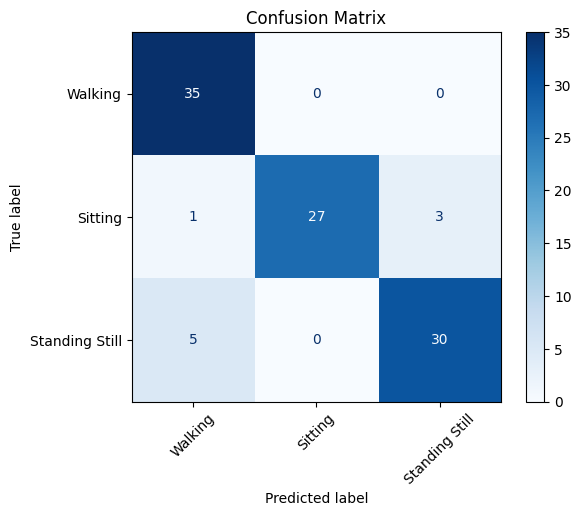

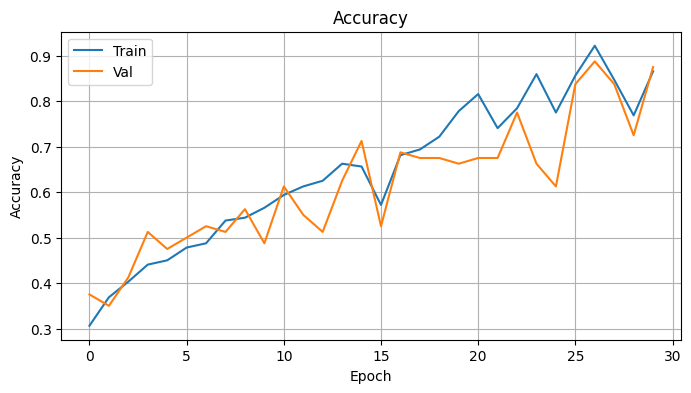


Classification Report:

                precision    recall  f1-score   support

       Walking       0.85      1.00      0.92        35
       Sitting       1.00      0.87      0.93        31
Standing Still       0.91      0.86      0.88        35

      accuracy                           0.91       101
     macro avg       0.92      0.91      0.91       101
  weighted avg       0.92      0.91      0.91       101

Model saved as fast_cnn_lstm_3classes.pth


In [13]:

def train_epoch(model, loader, opt, crit, scaler=None):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        opt.zero_grad(set_to_none=True)

        if scaler is not None:
            with torch.amp.autocast("cuda"):
                out = model(x)
                loss = crit(out, y)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
        else:
            out = model(x)
            loss = crit(out, y)
            loss.backward()
            opt.step()

        total_loss += loss.item() * y.size(0)
        pred = out.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total

@torch.inference_mode()
def eval_epoch(model, loader, crit):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        if AMP_ENABLED:
            with torch.amp.autocast("cuda"):
                out = model(x)
                loss = crit(out, y)
        else:
            out = model(x)
            loss = crit(out, y)

        total_loss += loss.item() * y.size(0)
        correct += (out.argmax(dim=1) == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total

print("\nTRAINING")
history = {"train_acc": [], "val_acc": [], "train_loss": [], "val_loss": []}

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, scaler)
    val_loss, val_acc = eval_epoch(model, val_loader, criterion)

    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(f"E{epoch+1}: Train Acc {train_acc:.3f}, Val Acc {val_acc:.3f}")

    if early_stop(val_acc, model):
        print("Early stopping")
        break

model.load_state_dict(torch.load("best_final.pth", map_location=device))
test_loss, test_acc = eval_epoch(model, test_loader, criterion)
print(f"\nTest Accuracy: {test_acc:.4f}")

@torch.inference_mode()
def collect_predictions(model, loader):
    model.eval()
    all_pred, all_true = [], []

    for x, y in loader:
        x = x.to(device, non_blocking=True)

        if AMP_ENABLED:
            with torch.amp.autocast("cuda"):
                out = model(x)
        else:
            out = model(x)

        pred = out.argmax(dim=1).cpu().numpy()
        all_pred.extend(pred)
        all_true.extend(y.numpy())

    return np.array(all_true), np.array(all_pred)

all_true, all_pred = collect_predictions(model, test_loader)

cm = confusion_matrix(all_true, all_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=SELECTED_CLASSES)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history["train_acc"], label="Train")
plt.plot(history["val_acc"], label="Val")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

print("\nClassification Report:\n")
print(classification_report(all_true, all_pred, target_names=SELECTED_CLASSES))
torch.save(model.state_dict(), "fast_cnn_lstm_3classes.pth")
print("Model saved as fast_cnn_lstm_3classes.pth")